In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

busi_path = "/content/drive/MyDrive/BUSI"

print(os.listdir(busi_path))

['images', 'labels', 'processed_images', 'best_attention_unet.keras']


In [9]:
import os

print("My Drive contains:")
print(os.listdir("/content/drive/MyDrive"))

print("\nBUSI contents:")
print(os.listdir("/content/drive/MyDrive/BUSI"))

My Drive contains:
['1000026209.jpeg', 'Classroom', '1000069692.jpeg', 'IMG-20240321-WA0006.jpg', '52-SIDDHI LAGAD-SMART ENGLISH BASICS FOR PROFESSIONALS  (1).pdf', '52- Siddhi Lagad-Turbo C++ (1).pdf', '52- Siddhi Lagad-Turbo C++.pdf', 'certificate.pdf', 'PYTHON CERTIFICATE (1).pdf', 'PYTHON CERTIFICATE.pdf', '52-SIDDHI LAGAD-SMART ENGLISH BASICS FOR PROFESSIONALS .pdf', 'Untitled document (5).gdoc', 'Experiment no 1 (2).gdoc', 'JAVA EXP 4.odt', 'JAVA EXP 4.gdoc', 'Copy of JAVA EXP 4.gdoc', 'Exp 4 A & B.odt', 'Exp 4 A & B.gdoc', 'JAVA Exp 4 A & B.docx', 'EXPERIMENT 2.gdoc', 'Module 1 PCPF.gslides', 'Experiment no 1 (1).gdoc', 'Experiment no 1.gdoc', 'dsl mm.gdoc', 'EXP 2 DSAL.gdoc', 'Atharva_Roll no-67_Java_Exp1a.pdf', 'Atharva_Roll no-67_JAVA_Exp2.pdf', 'Atharva_Roll no-67_JAVA_Exp3a.pdf', 'Atharva_Roll no-67_JAVA_Exp1b.pdf', 'Atharva_Roll no-67_JAVA_Exp3b.pdf', 'Siddhi 52 .gdoc', 'Siddhi 52 JAVA_Exp2.gdoc', 'Siddhi 52_JAVA_Exp3b.gdoc', 'Atharva_Roll no-67_Java_Exp1a.gdoc', 'Siddhi 5

In [10]:
image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"

In [11]:
import os

busi_path = "/content/drive/MyDrive/BUSI"

for root, dirs, files in os.walk(busi_path):
    print(root, "→", len(files), "files")

/content/drive/MyDrive/BUSI → 1 files
/content/drive/MyDrive/BUSI/images → 629 files
/content/drive/MyDrive/BUSI/labels → 629 files
/content/drive/MyDrive/BUSI/processed_images → 629 files


In [12]:
print("BUSI exists:", os.path.exists(busi_path))

BUSI exists: True


In [33]:
import os

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"

images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

labels = [
    f for f in os.listdir(label_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Total images:", len(images))
print("Total labels:", len(labels))

print("\nSample images:")
print(images[:5])

print("\nSample labels:")
print(labels[:5])

Total images: 629
Total labels: 629

Sample images:
['benign_1.png', 'benign_10.png', 'benign_101.png', 'benign_102.png', 'benign_103.png']

Sample labels:
['benign_1.png', 'benign_10.png', 'benign_101.png', 'benign_102.png', 'benign_103.png']


Class Distribution:
Benign       420
Malignant    209
Name: count, dtype: int64


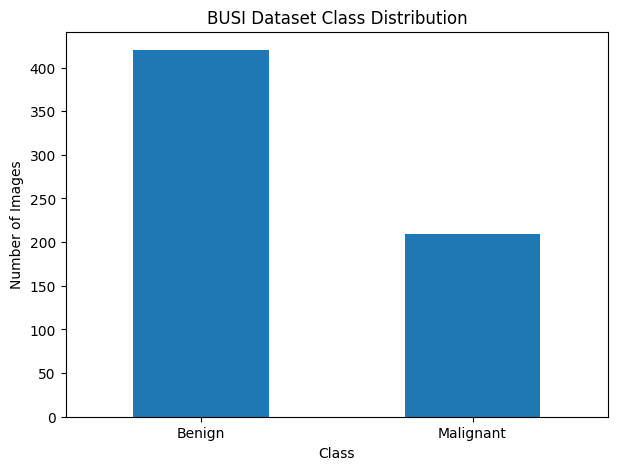

In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt

image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

def get_class(filename):
    filename = filename.lower()

    if filename.startswith("benign"):
        return "Benign"
    elif filename.startswith("malignant"):
        return "Malignant"
    elif filename.startswith("normal"):
        return "Normal"
    else:
        return "Unknown"

classes = [get_class(f) for f in image_files]

class_counts = pd.Series(classes).value_counts()

print("Class Distribution:")
print(class_counts)

plt.figure(figsize=(7,5))
class_counts.plot(kind="bar")

plt.title("BUSI Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [34]:
plt.figure(figsize=(7,5))

class_counts.plot(kind="bar")

plt.title("BUSI Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

NameError: name 'class_counts' is not defined

<Figure size 700x500 with 0 Axes>

In [15]:
import os

image_names = {os.path.splitext(f)[0] for f in images}
label_names = {os.path.splitext(f)[0] for f in labels}

common = image_names.intersection(label_names)

print("Images:", len(image_names))
print("Labels:", len(label_names))
print("Matching filenames:", len(common))

print("\nSample matching names:")
print(list(common)[:10])

Images: 629
Labels: 629
Matching filenames: 629

Sample matching names:
['benign_381', 'benign_210', 'malignant_92', 'benign_313', 'malignant_90', 'benign_43', 'malignant_162', 'benign_11', 'malignant_100', 'benign_265']


In [16]:
pairs = []

for name in sorted(common):
    image_file = os.path.join(image_dir, name + ".png")
    label_file = os.path.join(label_dir, name + ".png")

    if os.path.exists(image_file) and os.path.exists(label_file):
        pairs.append((image_file, label_file))

print("Total image-label pairs:", len(pairs))
print("\nFirst 5 pairs:")

for pair in pairs[:5]:
    print(pair)

Total image-label pairs: 629

First 5 pairs:
('/content/drive/MyDrive/BUSI/images/benign_1.png', '/content/drive/MyDrive/BUSI/labels/benign_1.png')
('/content/drive/MyDrive/BUSI/images/benign_10.png', '/content/drive/MyDrive/BUSI/labels/benign_10.png')
('/content/drive/MyDrive/BUSI/images/benign_101.png', '/content/drive/MyDrive/BUSI/labels/benign_101.png')
('/content/drive/MyDrive/BUSI/images/benign_102.png', '/content/drive/MyDrive/BUSI/labels/benign_102.png')
('/content/drive/MyDrive/BUSI/images/benign_103.png', '/content/drive/MyDrive/BUSI/labels/benign_103.png')


Image: benign_1.png
Mask: benign_1.png
Image shape: (471, 562, 3)
Mask shape: (471, 562)
Mask values: [0 1]


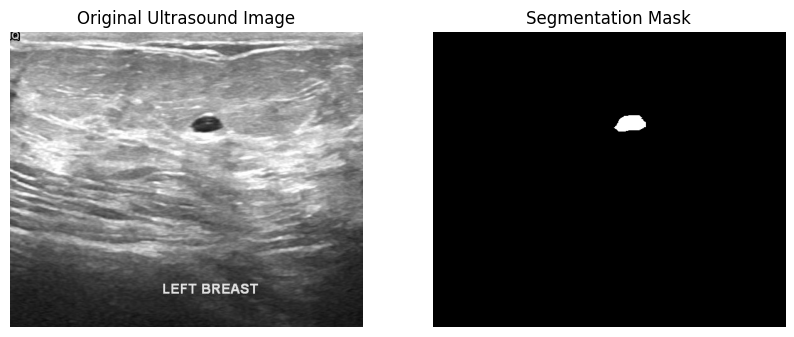

In [17]:
import cv2
import matplotlib.pyplot as plt

image_file, label_file = pairs[0]

image = cv2.imread(image_file)
mask = cv2.imread(label_file, cv2.IMREAD_GRAYSCALE)

print("Image:", os.path.basename(image_file))
print("Mask:", os.path.basename(label_file))
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Ultrasound Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

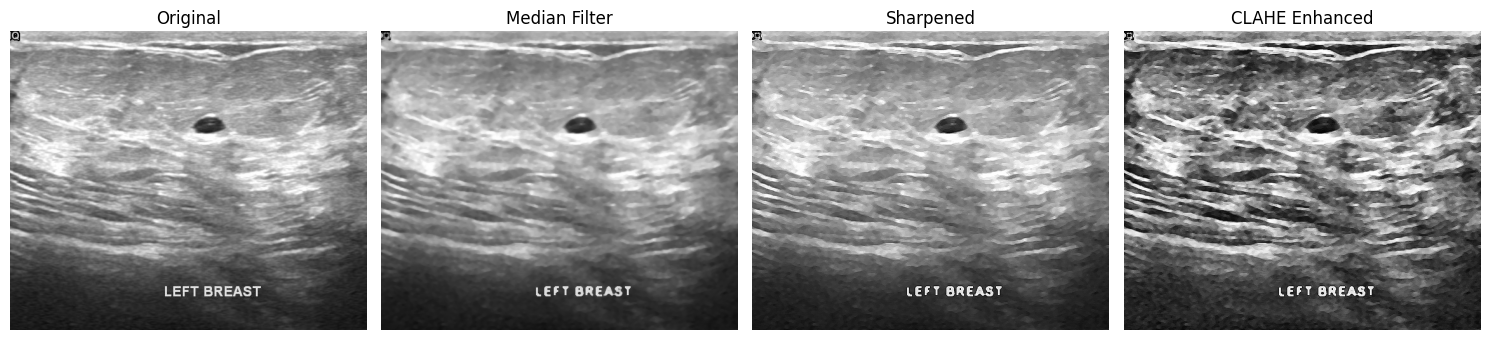

In [18]:
import cv2
import matplotlib.pyplot as plt

image_file, label_file = pairs[0]

img = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)

# 1. Median filtering
median = cv2.medianBlur(img, 5)

# 2. Sharpening
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(median, -1, kernel)

# 3. Gamma correction
gamma = 1.2
gamma_corrected = np.power(sharpened / 255.0, gamma) * 255
gamma_corrected = gamma_corrected.astype(np.uint8)

# 4. CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

final_image = clahe.apply(gamma_corrected)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(final_image, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
import os
import cv2
import numpy as np

processed_dir = "/content/drive/MyDrive/BUSI/processed_images"
os.makedirs(processed_dir, exist_ok=True)

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Median filtering
    median = cv2.medianBlur(img, 5)

    # Sharpening
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharpened = cv2.filter2D(median, -1, kernel)

    # Gamma correction
    gamma = 1.2
    gamma_corrected = np.power(
        sharpened / 255.0, gamma
    ) * 255
    gamma_corrected = gamma_corrected.astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(gamma_corrected)


for image_file, _ in pairs:
    processed = preprocess_image(image_file)

    filename = os.path.basename(image_file)
    save_path = os.path.join(processed_dir, filename)

    cv2.imwrite(save_path, processed)

print("Preprocessing completed!")
print("Processed images:", len(os.listdir(processed_dir)))

Preprocessing completed!
Processed images: 629


In [20]:
from sklearn.model_selection import train_test_split
import os

# Get class from filename
def get_class(filename):
    if filename.startswith("benign"):
        return "benign"
    elif filename.startswith("malignant"):
        return "malignant"
    else:
        return "normal"

# Create dataset records
data = []

for image_file, label_file in pairs:
    filename = os.path.basename(image_file)

    if os.path.exists(
        os.path.join(processed_dir, filename)
    ):
        data.append({
            "image": os.path.join(processed_dir, filename),
            "label": label_file,
            "class": get_class(filename)
        })

print("Total usable samples:", len(data))

Total usable samples: 629


In [21]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=[x["class"] for x in data]
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=[x["class"] for x in temp_data]
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_data))

Training samples: 503
Validation samples: 63
Testing samples: 63


In [22]:
IMG_SIZE = 256

def prepare_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(np.float32) / 255.0

    return image


def prepare_mask(mask_path):
    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    # Convert 0/1 mask to binary
    mask = (mask > 0).astype(np.float32)

    return mask

In [23]:
sample = train_data[0]

image = prepare_image(sample["image"])
mask = prepare_mask(sample["label"])

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Image range:", image.min(), "to", image.max())
print("Mask values:", np.unique(mask))

Image shape: (256, 256)
Mask shape: (256, 256)
Image range: 0.003921569 to 1.0
Mask values: [0. 1.]


In [24]:
import tensorflow as tf
import numpy as np

def create_dataset(data):
    images = []
    masks = []

    for sample in data:
        img = prepare_image(sample["image"])
        mask = prepare_mask(sample["label"])

        # Add channel dimension
        img = np.expand_dims(img, axis=-1)
        mask = np.expand_dims(mask, axis=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images, dtype=np.float32), \
           np.array(masks, dtype=np.float32)


X_train, Y_train = create_dataset(train_data)
X_val, Y_val = create_dataset(val_data)
X_test, Y_test = create_dataset(test_data)

print("Training images:", X_train.shape)
print("Training masks:", Y_train.shape)

print("Validation images:", X_val.shape)
print("Validation masks:", Y_val.shape)

print("Testing images:", X_test.shape)
print("Testing masks:", Y_test.shape)

Training images: (503, 256, 256, 1)
Training masks: (503, 256, 256, 1)
Validation images: (63, 256, 256, 1)
Validation masks: (63, 256, 256, 1)
Testing images: (63, 256, 256, 1)
Testing masks: (63, 256, 256, 1)


In [25]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Concatenate, Activation, Add, Multiply
)
from tensorflow.keras.models import Model


# Attention Gate
def attention_gate(x, skip, filters):
    g = Conv2D(filters, 1, padding="same")(x)
    s = Conv2D(filters, 1, padding="same")(skip)

    g = tf.keras.layers.BatchNormalization()(g)
    s = tf.keras.layers.BatchNormalization()(s)

    attention = Add()([g, s])
    attention = Activation("relu")(attention)

    attention = Conv2D(1, 1, padding="same")(attention)
    attention = Activation("sigmoid")(attention)

    return Multiply()([skip, attention])


# Convolution block
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = Conv2D(filters, 3, padding="same", activation="relu")(x)
    return x


# Attention U-Net
def attention_unet(input_shape=(256, 256, 1)):

    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D(2)(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D(2)(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D(2)(c3)

    c4 = conv_block(p3, 256)
    p4 = MaxPooling2D(2)(c4)

    # Bottleneck
    bottleneck = conv_block(p4, 512)

    # Decoder
    u4 = UpSampling2D(2)(bottleneck)
    a4 = attention_gate(u4, c4, 256)
    u4 = Concatenate()([u4, a4])
    c5 = conv_block(u4, 256)

    u3 = UpSampling2D(2)(c5)
    a3 = attention_gate(u3, c3, 128)
    u3 = Concatenate()([u3, a3])
    c6 = conv_block(u3, 128)

    u2 = UpSampling2D(2)(c6)
    a2 = attention_gate(u2, c2, 64)
    u2 = Concatenate()([u2, a2])
    c7 = conv_block(u2, 64)

    u1 = UpSampling2D(2)(c7)
    a1 = attention_gate(u1, c1, 32)
    u1 = Concatenate()([u1, a1])
    c8 = conv_block(u1, 32)

    outputs = Conv2D(1, 1, activation="sigmoid")(c8)

    return Model(inputs, outputs)


model = attention_unet()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │    131,328 │ up_sampling2d[0]

 Total params: 8,112,485 (30.95 MB)

 Trainable params: 8,110,565 (30.94 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [26]:
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        smooth
    )


def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(
        y_true, y_pred
    )

    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=combined_loss,
    metrics=[
        dice_coefficient,
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("Attention U-Net compiled successfully!")

Attention U-Net compiled successfully!


In [27]:
import tensorflow as tf

print("GPU available:", tf.config.list_physical_devices("GPU"))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
!nvidia-smi

Tue Oct  6 16:03:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P0             28W /   70W |     169MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "/content/drive/MyDrive/BUSI/best_attention_unet.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=20,
    batch_size=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8620 - dice_coefficient: 0.1486 - loss: 1.2728 - val_accuracy: 0.9052 - val_dice_coefficient: 0.1416 - val_loss: 1.1418
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 282ms/step - accuracy: 0.9066 - dice_coefficient: 0.2879 - loss: 0.9560 - val_accuracy: 0.9052 - val_dice_coefficient: 0.1714 - val_loss: 1.0759
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 274ms/step - accuracy: 0.9074 - dice_coefficient: 0.4098 - loss: 0.8414 - val_accuracy: 0.9052 - val_dice_coefficient: 0.1185 - val_loss: 1.1614
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.9211 - dice_coefficient: 0.4625 - loss: 0.7668 - val_accuracy: 0.9081 - val_dice_coefficient: 0.2236 - val_loss: 1.0002
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 298ms/step - accuracy: 0.9183 - dice_coefficient: 0.4649 - loss: 0.7720 - val_accuracy: 0.9131 - val_dice_coefficient: 0.2536 - val_loss: 0.9783
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.

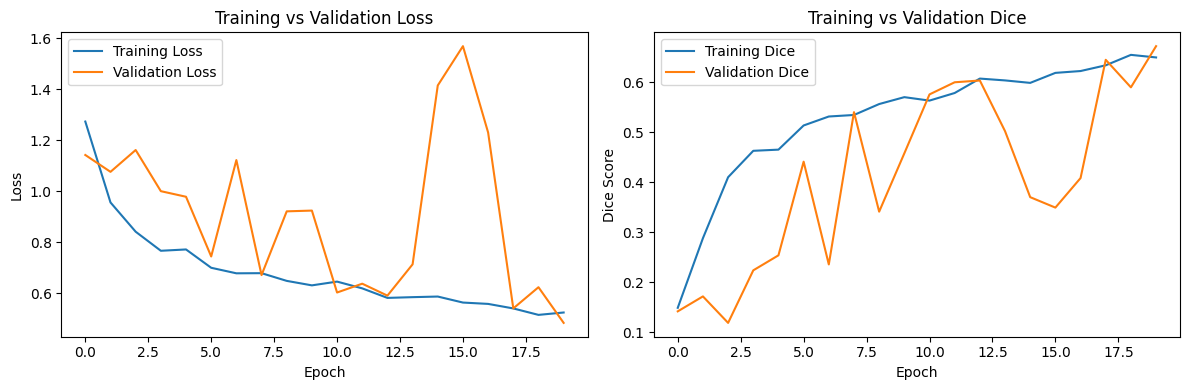

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    history.history["dice_coefficient"],
    label="Training Dice"
)
plt.plot(
    history.history["val_dice_coefficient"],
    label="Validation Dice"
)
plt.title("Training vs Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
import os

busi_path = "/content/drive/MyDrive/BUSI"

print(os.listdir(busi_path))

['images', 'labels', 'processed_images', 'best_attention_unet.keras']


In [11]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"
processed_dir = "/content/drive/MyDrive/BUSI/processed_images"

# Get matching filenames
images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

labels = [
    f for f in os.listdir(label_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

image_names = {os.path.splitext(f)[0] for f in images}
label_names = {os.path.splitext(f)[0] for f in labels}
common = image_names.intersection(label_names)

# Create pairs
pairs = []

for name in sorted(common):
    image_file = os.path.join(processed_dir, name + ".png")
    label_file = os.path.join(label_dir, name + ".png")

    if os.path.exists(image_file) and os.path.exists(label_file):
        pairs.append((image_file, label_file))

# Get class
def get_class(filename):
    if filename.startswith("benign"):
        return "benign"
    elif filename.startswith("malignant"):
        return "malignant"
    else:
        return "normal"

data = []

for image_file, label_file in pairs:
    filename = os.path.basename(image_file)

    data.append({
        "image": image_file,
        "label": label_file,
        "class": get_class(filename)
    })

# Same split as before
train_data, temp_data = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=[x["class"] for x in data]
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=[x["class"] for x in temp_data]
)

print("Test samples:", len(test_data))

Test samples: 63


In [13]:
import cv2
import numpy as np

IMG_SIZE = 256

X_test = []
Y_test = []

for sample in test_data:

    # Prepare image
    img = cv2.imread(sample["image"], cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0

    # Prepare mask
    mask = cv2.imread(
        sample["label"],
        cv2.IMREAD_GRAYSCALE
    )
    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )
    mask = (mask > 0).astype(np.float32)

    # Add channel
    X_test.append(np.expand_dims(img, axis=-1))
    Y_test.append(np.expand_dims(mask, axis=-1))

X_test = np.array(X_test, dtype=np.float32)
Y_test = np.array(Y_test, dtype=np.float32)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_test: (63, 256, 256, 1)
Y_test: (63, 256, 256, 1)


In [14]:
Y_pred = model.predict(X_test)

Y_pred_binary = (Y_pred > 0.5).astype(np.float32)

print("Prediction shape:", Y_pred_binary.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 6s/step
Prediction shape: (63, 256, 256, 1)


In [17]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Flatten masks
y_true = Y_test.flatten()
y_pred = Y_pred_binary.flatten()

# Dice Score
intersection = np.sum(y_true * y_pred)
dice = (2 * intersection + 1e-7) / (
    np.sum(y_true) + np.sum(y_pred) + 1e-7
)

# IoU
union = np.sum(y_true) + np.sum(y_pred) - intersection
iou = (intersection + 1e-7) / (union + 1e-7)

# Precision
precision = precision_score(
    y_true, y_pred, zero_division=0
)

# Recall
recall = recall_score(
    y_true, y_pred, zero_division=0
)

# Accuracy
accuracy = accuracy_score(
    y_true, y_pred
)

print("----- MODEL EVALUATION -----")
print(f"Dice Score : {dice:.4f}")
print(f"IoU        : {iou:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"Accuracy   : {accuracy:.4f}")

----- MODEL EVALUATION -----
Dice Score : 0.7344
IoU        : 0.5803
Precision  : 0.7994
Recall     : 0.6793
Accuracy   : 0.9469


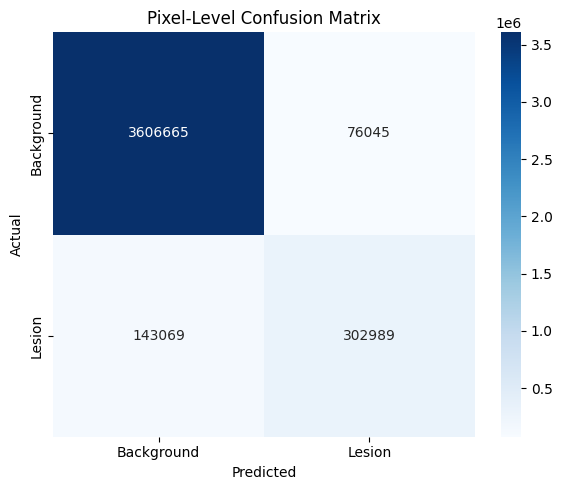

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Background", "Lesion"],
    yticklabels=["Background", "Lesion"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Pixel-Level Confusion Matrix")

plt.tight_layout()
plt.show()

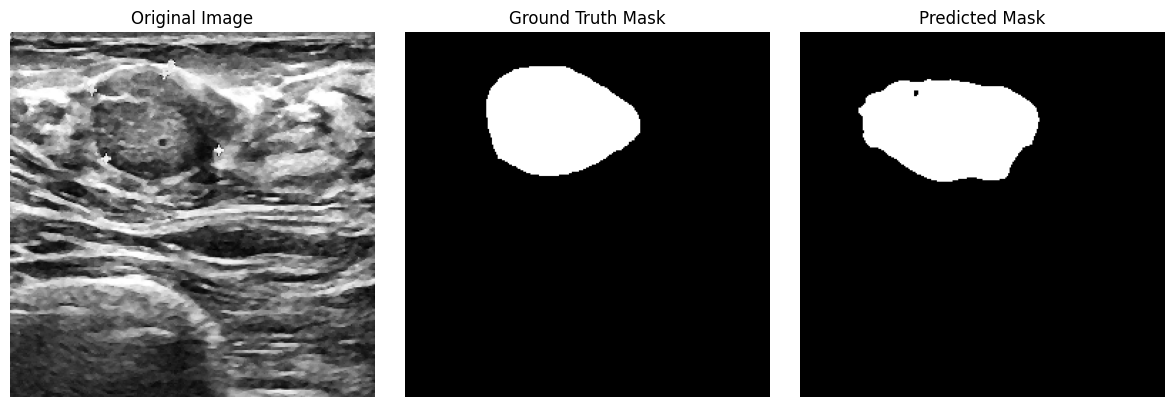

In [20]:
index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y_test[index].squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Y_pred_binary[index].squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
!pip install -q gradio

In [29]:
def predict_lesion(image):

    # Convert input to numpy
    image = np.array(image)

    # RGB/RGBA → grayscale
    if image.ndim == 3:
        if image.shape[-1] == 4:
            image = cv2.cvtColor(image, cv2.COLOR_RGBA2GRAY)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Preprocessing
    median = cv2.medianBlur(image, 5)

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharpened = cv2.filter2D(median, -1, kernel)

    gamma_corrected = np.power(
        sharpened / 255.0,
        1.2
    ) * 255

    gamma_corrected = gamma_corrected.astype(np.uint8)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gamma_corrected)

    # Resize + normalize
    resized = cv2.resize(enhanced, (256, 256))
    normalized = resized.astype(np.float32) / 255.0

    # Add batch and channel dimensions
    input_image = normalized[np.newaxis, ..., np.newaxis]

    # Prediction
    prediction = model.predict(input_image, verbose=0)

    # Mask
    mask = (prediction[0, :, :, 0] > 0.5).astype(np.uint8) * 255

    return resized, mask

In [30]:
import gradio as gr

demo = gr.Interface(
    fn=predict_lesion,
    inputs=gr.Image(type="numpy"),
    outputs=[
        gr.Image(label="Processed Ultrasound"),
        gr.Image(label="Predicted Lesion Mask")
    ],
    title="Breast Cancer Lesion Segmentation",
    description="Attention U-Net based breast ultrasound lesion segmentation."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b30a550ac16a2bff22.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [27]:
print("Model:", model)
print("X_test shape:", X_test.shape)

Model: <Functional name=functional, built=True>
X_test shape: (63, 256, 256, 1)


In [28]:
import time

start = time.time()

test_batch = X_test[:1]

print("Starting prediction...")

test_prediction = model.predict(
    test_batch,
    verbose=1
)

print("Prediction finished!")
print("Shape:", test_prediction.shape)
print("Time:", time.time() - start, "seconds")

Starting prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Prediction finished!
Shape: (1, 256, 256, 1)
Time: 0.22418761253356934 seconds


In [31]:
model.save(
    "/content/drive/MyDrive/BUSI/final_attention_unet.keras"
)

print("Final model saved successfully!")

Final model saved successfully!


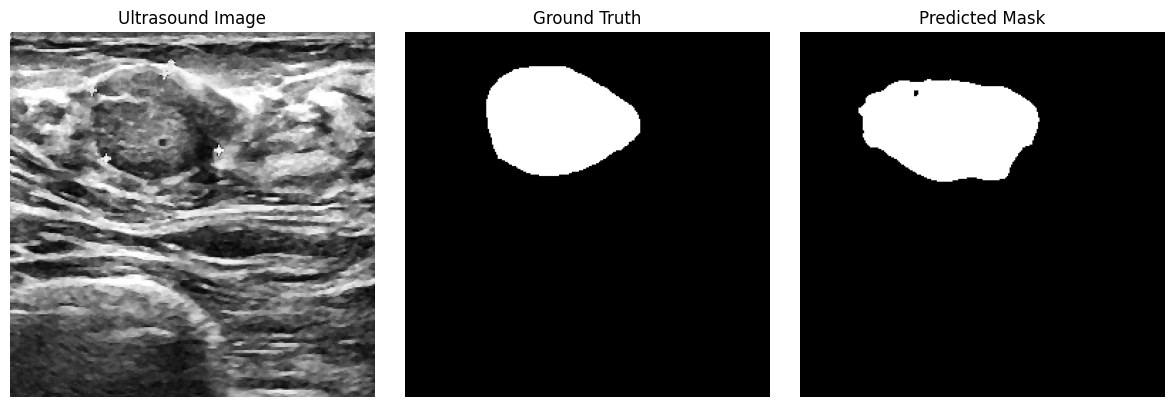

In [32]:
import matplotlib.pyplot as plt

index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.title("Ultrasound Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y_test[index].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Y_pred_binary[index].squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
from PIL import Image
import os
import pandas as pd

image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

dimensions = []

for filename in image_files:
    path = os.path.join(image_dir, filename)

    with Image.open(path) as img:
        dimensions.append(img.size)

dimension_df = pd.DataFrame(
    dimensions,
    columns=["Width", "Height"]
)

print("Image Dimensions Summary:")
print(dimension_df.describe())

print("\nUnique Image Dimensions:")
print(dimension_df.drop_duplicates().to_string(index=False))

Image Dimensions Summary:
             Width      Height
count   629.000000  629.000000
mean    607.426073  494.699523
std     119.841747   72.955665
min     190.000000  324.000000
25%     554.000000  463.000000
50%     563.000000  473.000000
75%     683.000000  571.000000
max    1048.000000  719.000000

Unique Image Dimensions:
 Width  Height
   562     471
   683     585
   563     473
   634     610
   766     585
   777     578
   882     581
   808     716
   759     616
   769     582
   562     470
   689     587
   555     468
   315     477
   652     612
   810     695
   757     575
   554     469
   766     588
   806     688
   653     620
   762     585
   678     571
   808     695
   646     610
   774     577
   648     610
   645     614
   756     578
   771     570
   558     476
   549     475
   775     587
   558     474
   587     435
   552     483
   369     342
   378     345
   776     582
   886     581
   766     600
   563     468
   699     531
   452   

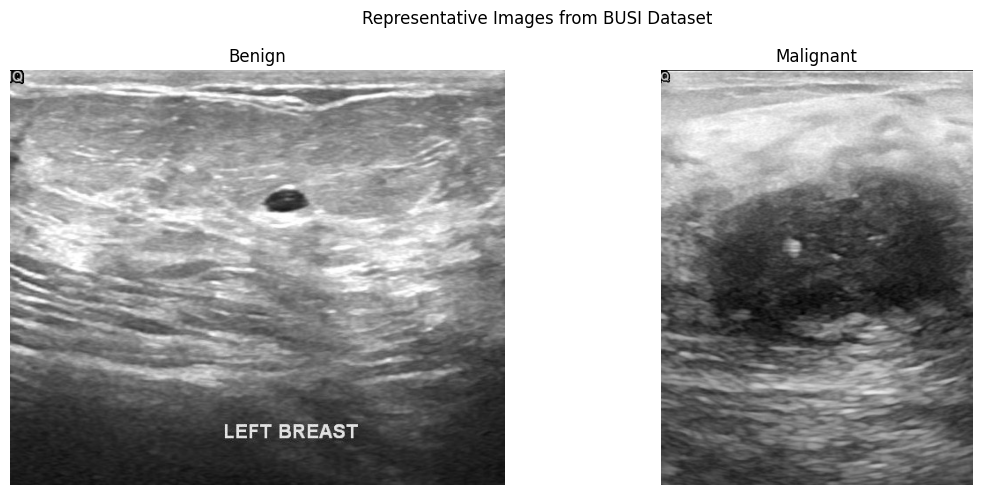

In [41]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

benign_files = [f for f in image_files if "benign" in f.lower()]
malignant_files = [f for f in image_files if "malignant" in f.lower()]

# Select one image from each class
selected = [
    ("Benign", benign_files[0]),
    ("Malignant", malignant_files[0])
]

plt.figure(figsize=(12, 5))

for i, (class_name, filename) in enumerate(selected):
    image_path = os.path.join(image_dir, filename)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Representative Images from BUSI Dataset")
plt.tight_layout()
plt.show()

In [42]:
import os
import cv2
import numpy as np

image_dir = "/content/drive/MyDrive/BUSI/images"
label_dir = "/content/drive/MyDrive/BUSI/labels"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

lesion_percentages = []

for filename in image_files:
    label_path = os.path.join(label_dir, filename)

    if os.path.exists(label_path):
        mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

        if mask is not None:
            lesion_pixels = np.sum(mask > 0)
            total_pixels = mask.shape[0] * mask.shape[1]

            percentage = (lesion_pixels / total_pixels) * 100
            lesion_percentages.append(percentage)

print("Number of masks analyzed:", len(lesion_percentages))

print("Average lesion area:",
      round(np.mean(lesion_percentages), 2), "%")

print("Minimum lesion area:",
      round(np.min(lesion_percentages), 2), "%")

print("Maximum lesion area:",
      round(np.max(lesion_percentages), 2), "%")

Number of masks analyzed: 629
Average lesion area: 9.39 %
Minimum lesion area: 0.28 %
Maximum lesion area: 56.29 %


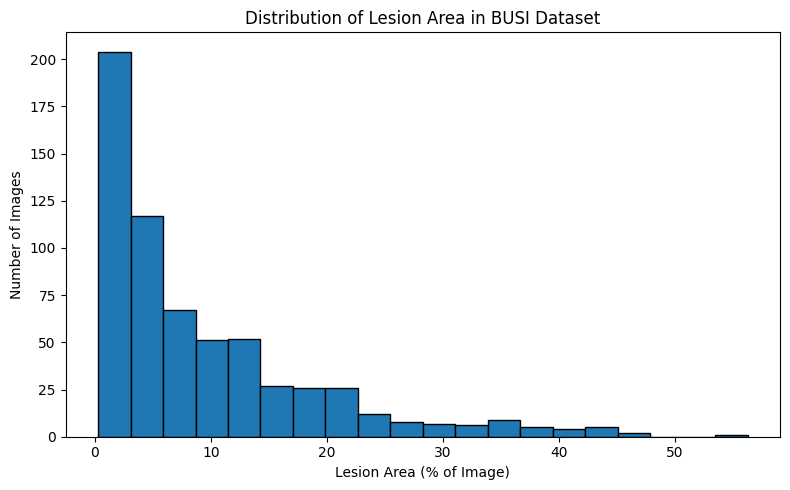

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    lesion_percentages,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Lesion Area in BUSI Dataset")
plt.xlabel("Lesion Area (% of Image)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

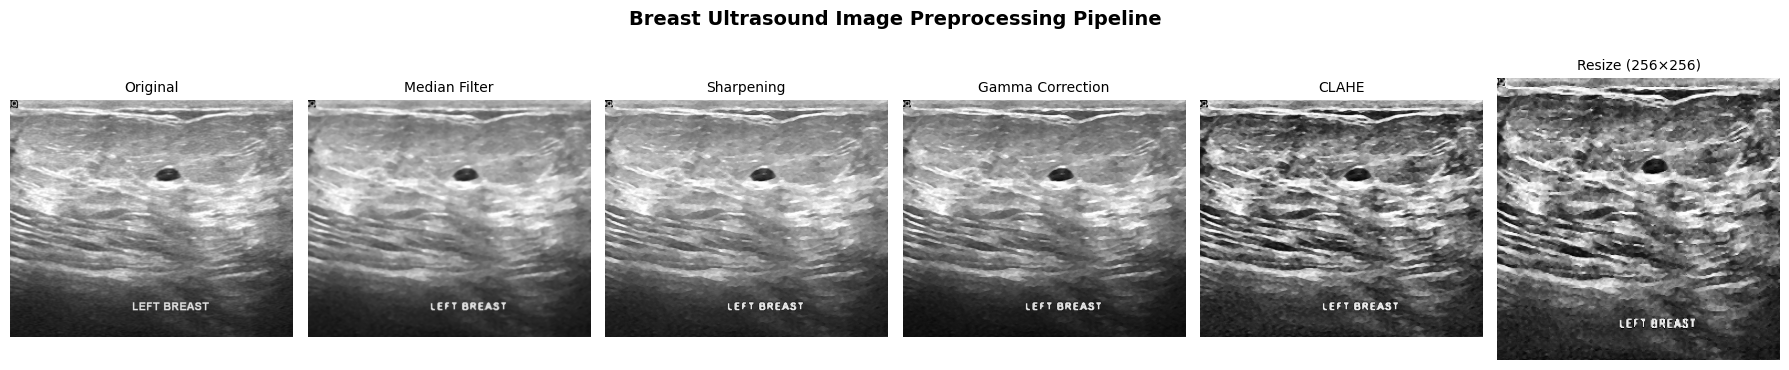

Figure saved at:
/content/drive/MyDrive/BUSI/preprocessing_pipeline.png


In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Select one ultrasound image
image_dir = "/content/drive/MyDrive/BUSI/images"

image_files = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

# Use first benign image
filename = [f for f in image_files if "benign" in f.lower()][0]
image_path = os.path.join(image_dir, filename)

# Read image in grayscale
original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Median Filtering
median = cv2.medianBlur(original, 5)

# 2. Sharpening
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(median, -1, kernel)

# 3. Gamma Correction
gamma = 1.2
gamma_corrected = np.power(
    sharpened / 255.0,
    gamma
) * 255

gamma_corrected = gamma_corrected.astype(np.uint8)

# 4. CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_image = clahe.apply(gamma_corrected)

# 5. Resize
resized = cv2.resize(clahe_image, (256, 256))

# Display all stages
plt.figure(figsize=(18, 4))

images = [
    original,
    median,
    sharpened,
    gamma_corrected,
    clahe_image,
    resized
]

titles = [
    "Original",
    "Median Filter",
    "Sharpening",
    "Gamma Correction",
    "CLAHE",
    "Resize (256×256)"
]

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i], fontsize=10)
    plt.axis("off")

plt.suptitle(
    "Breast Ultrasound Image Preprocessing Pipeline",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Save figure to Google Drive
save_path = "/content/drive/MyDrive/BUSI/preprocessing_pipeline.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved at:")
print(save_path)